In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

#### Download data

In [2]:
df = pd.read_csv("features_new.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Shape:', df.shape)
display(df.head())

Shape: (26448, 65)


,date,alarm_count,alarm_total_duration_min,alarm_all_region,city_address,day_tempmax,day_tempmin,day_temp,day_humidity,day_windspeed,...,weather_Snow_Freezing_Drizzle/Freezing_Rain_Overcast,weather_Snow_Freezing_Drizzle/Freezing_Rain_Partially_cloudy,weather_Snow_Overcast,weather_Snow_Partially_cloudy,weather_Snow_Rain,weather_Snow_Rain_Freezing_Drizzle/Freezing_Rain_Overcast,weather_Snow_Rain_Freezing_Drizzle/Freezing_Rain_Partially_cloudy,weather_Snow_Rain_Ice_Overcast,weather_Snow_Rain_Overcast,weather_Snow_Rain_Partially_cloudy
0,2022-02-24,0.0,0.0,0.0,"Ivano-Frankivsk,Ukraine",5.7,0.1,2.7,75.2,15.1,...,False,False,False,False,False,False,False,False,False,True
1,2022-02-24,0.0,0.0,0.0,"Chernivtsi,Ukraine",6.5,-0.2,3.4,74.9,17.9,...,False,False,False,True,False,False,False,False,False,False
2,2022-02-24,1.0,30.0,1.0,"Vinnytsia,Ukraine",5.0,0.7,2.8,80.5,10.8,...,False,False,False,False,False,False,False,False,False,True
3,2022-02-24,0.0,0.0,0.0,"Cherkasy,Ukraine",4.9,-0.1,1.9,83.4,8.3,...,False,False,False,False,False,False,False,False,False,False
4,2022-02-24,0.0,0.0,0.0,"Dnipro,Ukraine",8.0,-2.0,3.1,70.6,21.6,...,False,False,False,False,False,False,False,False,False,False


#### Set target

In [3]:
TARGET = 'target_alarm_next_day'

LEAKAGE_COLS = [
    'alarm_all_region',
]

X = (df
     .select_dtypes(include=[np.number, bool])
     .drop(columns=[TARGET] + LEAKAGE_COLS, errors='ignore')
     .fillna(0)
     .astype(float)) 

y = df[TARGET].astype(int)

feature_cols = X.columns.tolist()
print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'\nTarget distibution:\n{y.value_counts()}')

Features (57): ['alarm_count', 'alarm_total_duration_min', 'day_tempmax', 'day_tempmin', 'day_temp', 'day_humidity', 'day_windspeed', 'reddit_post_count', 'reddit_avg_score', 'text_intensity_index', 'alarm_lag1', 'alarm_lag2', 'alarm_roll7_mean', 'duration_lag1', 'region_Івано_Франківська_обл', 'region_Волинська_обл', 'region_Вінницька_обл', 'region_Дніпропетровська_обл', 'region_Донецька_обл', 'region_Житомирська_обл', 'region_Закарпатська_обл', 'region_Запорізька_обл', 'region_Київ', 'region_Київська_обл', 'region_Кіровоградська_обл', 'region_Львівська_обл', 'region_Миколаївська_обл', 'region_Одеська_обл', 'region_Полтавська_обл', 'region_Рівненська_обл', 'region_Сумська_обл', 'region_Тернопільська_обл', 'region_Харківська_обл', 'region_Херсонська_обл', 'region_Хмельницька_обл', 'region_Черкаська_обл', 'region_Чернівецька_обл', 'region_Чернігівська_обл', 'weather_Clear', 'weather_Overcast', 'weather_Partially_cloudy', 'weather_Rain', 'weather_Rain_Freezing_Drizzle/Freezing_Rain_Overc

#### Time split

In [4]:
rows_per_day = df.groupby('date').size().mean()
test_size = int(rows_per_day * 30)
print(f'Рядків/день: {rows_per_day:.0f}  →  test_size={test_size}')

tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=test_size,
    gap=0
)

Рядків/день: 24  →  test_size=720


#### Model tuning

In [5]:
base_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],       
    'max_depth': [5, 10, 15, 20, None],         
    'min_samples_split': [2, 5, 10],            
    'min_samples_leaf': [1, 2, 4],              
    'max_features': ['sqrt', 'log2']            
}

tscv_tune = TimeSeriesSplit(n_splits=3, test_size=test_size)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_grid,
    n_iter=20, 
    cv=tscv_tune,
    scoring='f1_macro', 
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X.values, y.values)

print('Найкращі параметри:')
print(search.best_params_)
print(f'\nНайкращий F1_macro (cv): {search.best_score_:.3f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Найкращі параметри:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}

Найкращий F1_macro (cv): 0.780


#### Fold evaluation

In [6]:
best_rf = search.best_estimator_

acc_scores = []
f1_scores  = []
y_test_last = None
y_pred_last = None

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_idx].values
    X_test  = X.iloc[test_idx].values
    y_train = y.iloc[train_idx].values
    y_test  = y.iloc[test_idx].values

    best_rf.fit(X_train, y_train)
    y_pred = best_rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    acc_scores.append(acc)
    f1_scores.append(f1)

    if fold == 4: 
        y_test_last = y_test
        y_pred_last = y_pred

    print(f'Fold {fold+1} │ train={len(train_idx):,}  test={len(test_idx):,} │ acc={acc:.3f}  f1_macro={f1:.3f}')

print()
print(f'Mean  │ acc={np.mean(acc_scores):.3f} ±{np.std(acc_scores):.3f}  │  f1_macro={np.mean(f1_scores):.3f} ±{np.std(f1_scores):.3f}')

Fold 1 │ train=22,848  test=720 │ acc=0.838  f1_macro=0.801
Fold 2 │ train=23,568  test=720 │ acc=0.822  f1_macro=0.771
Fold 3 │ train=24,288  test=720 │ acc=0.782  f1_macro=0.742
Fold 4 │ train=25,008  test=720 │ acc=0.825  f1_macro=0.792
Fold 5 │ train=25,728  test=720 │ acc=0.835  f1_macro=0.807

Mean  │ acc=0.820 ±0.020  │  f1_macro=0.783 ±0.024


#### Confusion matrix

In [7]:
print('Confusion matrix (fold 5):')
print(confusion_matrix(y_test_last, y_pred_last))
print()
print(classification_report(y_test_last, y_pred_last, zero_division=0))

Confusion matrix (fold 5):
[[164  52]
 [ 67 437]]

              precision    recall  f1-score   support

           0       0.71      0.76      0.73       216
           1       0.89      0.87      0.88       504

    accuracy                           0.83       720
   macro avg       0.80      0.81      0.81       720
weighted avg       0.84      0.83      0.84       720



#### Top-20 features

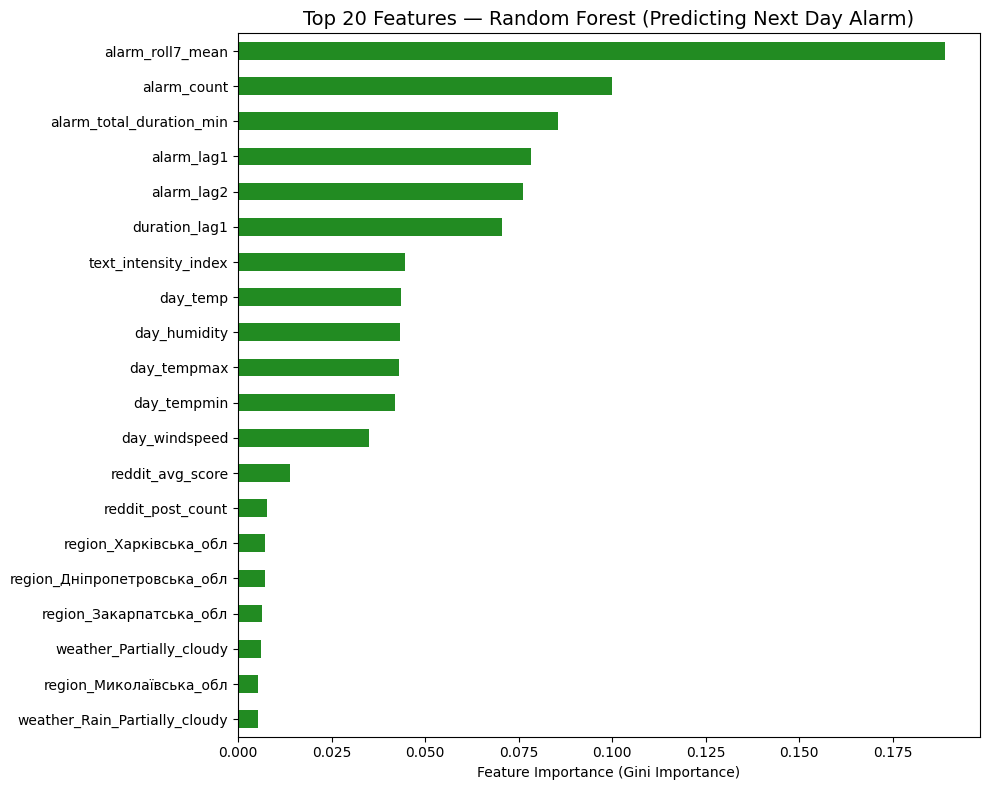

In [8]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='forestgreen')
ax.set_title('Top 20 Features — Random Forest (Predicting Next Day Alarm)', fontsize=14)
ax.set_xlabel('Feature Importance (Gini Importance)')
plt.tight_layout()
plt.show()

In [9]:
import joblib

joblib.dump(search.best_estimator_, 'model_randomforest.pkl')

['model_randomforest.pkl']